### Edge
- 엣지는 LangGraph에서 노드 간의 연결과 실행 흐름을 정의하는 핵심 요소
- 그래프의 각 노드가 연결되는 "길(path)"이라고 생각할 수 있으며, 데이터가 한 노드에서 다른 노드로 흐르는 경로
  - **방향성**: 한 노드에서 다른 노드로의 단방향 연결
  - **상태 전달**: 노드 간 상태 정보 전달
  - **흐름 제어**: 실행 순서와 조건 결정
  - **병렬 실행**: 여러 엣지가 동시에 활성화 가능

<br>

#### 기본 엣지 구조

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from visualize_graph import visualize_graph

In [2]:
class State(TypedDict):
    counter: int
    message: str

- 노드 정의

In [3]:
def increment(state: State) -> dict:
    """카운터를 증가시키는 노드"""
    return {
        "counter": state["counter"] + 1,
        "message": f"카운터 증가: {state['counter']} -> {state['counter'] + 1}"
    }

In [4]:
def double(state: State) -> dict:
    """카운터를 두 배로 만드는 노드"""
    return {
        "counter": state["counter"] * 2,
        "message": f"카운터 두 배: {state['counter']} -> {state['counter'] * 2}"
    }

- 그래프 생성

In [5]:
graph = StateGraph(State)

- 노드 & 엣지 추가

In [7]:
# 노드 추가
graph.add_node("increment", increment)
graph.add_node("double", double)

# 엣지 추가 - 기본 패턴
graph.add_edge(START, "increment")     # 시작 -> increment
graph.add_edge("increment", "double")   # increment -> double
graph.add_edge("double", END)     

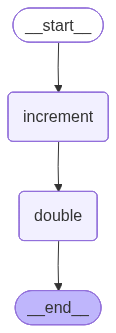

In [10]:
graph = graph.compile()
visualize_graph(graph)

<br>

#### 엣지 타입
- **일반 엣지 (Normal Edge)** : 두 노드를 직접 연결하는 가장 기본적인 형태. 첫 번째 노드가 완료되면 자동으로 두 번째 노드가 실행

```python
graph.add_edge("node_a", "node_b")
```

<br>

- **시작 엣지 (Start Edge)** : 그래프 실행의 진입점을 정의. `START`에서 지정된 노드로 실행이 시작

```python
graph.add_edge(START, "first_node")
```

<br>



- **종료 엣지 (End Edge)** : 그래프 실행의 종료점을 정의. 해당 노드가 완료되면 그래프 실행이 종료

```python
graph.add_edge("last_node", END)
```

<br>


- **조건부 엣지 (Conditional Edge)** : 상태나 조건에 따라 다음 노드를 동적으로 결정. `routing_function`이 반환하는 값에 따라 다른 노드로 분기

```python
graph.add_conditional_edges(
    "decision_node",
    routing_function,
    {
        "option_a": "node_a",
        "option_b": "node_b"
    }
)
```

<br>

### 엣지의 역할과 기능
- LangGraph에서 엣지(Edge)는 노드들 간의 연결을 정의하는 핵심 구성 요소로, 그래프의 실행 흐름과 데이터 전달을 제어하는 중요한 역할을 담당
- **엣지는 단순한 연결선이 아니라 워크플로우의 논리적 구조와 실행 순서를 결정하는 제어 구조**

<br>

#### 실행 순서 정의
- 엣지를 통해 노드들 간의 순차적 실행 체인을 구성할 수 있으며, 이는 복잡한 워크플로우를 논리적이고 예측 가능한 단계로 분해
  - **`START → step1 → step2 → step3 → END`와 같은 선형 흐름뿐만 아니라, 분기와 병합이 포함된 복잡한 실행 경로도 정의**
- **실행 순서의 정의에서 특히 중요한 것은 의존성 관리**
  - 각 노드가 이전 단계의 완료를 전제로 동작할 수 있도록 보장하며, 데이터 처리 파이프라인에서 각 단계가 올바른 입력을 받을 수 있도록 조율
  - **데이터 무결성과 처리 일관성을 보장하는 핵심 메커니즘**

<br>



In [12]:
class WorkflowState(TypedDict):
    data: str
    steps_completed: list
    status: str


- 노드 함수 정의

In [13]:
def step1(state: WorkflowState) -> dict:
    """첫 번째 처리 단계"""
    return {
        "data": state["data"] + " -> Step1",
        "steps_completed": state.get("steps_completed", []) + ["step1"],
        "status": "step1_complete"
    }

def step2(state: WorkflowState) -> dict:
    """두 번째 처리 단계"""
    return {
        "data": state["data"] + " -> Step2",
        "steps_completed": state["steps_completed"] + ["step2"],
        "status": "step2_complete"
    }

def step3(state: WorkflowState) -> dict:
    """세 번째 처리 단계"""
    return {
        "data": state["data"] + " -> Step3",
        "steps_completed": state["steps_completed"] + ["step3"],
        "status": "workflow_complete"
    }

- 노드 & 엣지 구성

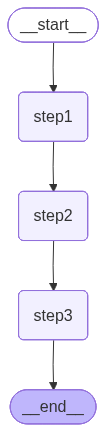

In [14]:
# 순차적 실행 흐름 정의
workflow = StateGraph(WorkflowState)
workflow.add_node("step1", step1)
workflow.add_node("step2", step2)
workflow.add_node("step3", step3)

# 엣지로 실행 순서 정의
workflow.add_edge(START, "step1")    # 1. 시작 -> step1
workflow.add_edge("step1", "step2")  # 2. step1 -> step2
workflow.add_edge("step2", "step3")  # 3. step2 -> step3
workflow.add_edge("step3", END)      # 4. step3 -> 종료

compiled_workflow = workflow.compile()
visualize_graph(compiled_workflow)

In [15]:
result = compiled_workflow.invoke({
    "data": "Start",
    "steps_completed": [],
    "status": "initialized"
})

print(f"최종 데이터: {result['data']}")
print(f"완료된 단계: {result['steps_completed']}")
print(f"상태: {result['status']}")

최종 데이터: Start -> Step1 -> Step2 -> Step3
완료된 단계: ['step1', 'step2', 'step3']
상태: workflow_complete


<br>

#### 흐름 제어 (조건부 엣지)
- 조건부 분기를 통해 런타임 상황에 따라 다른 실행 경로를 선택
- **`add_conditional_edges`를 통해 구현되는 이 기능은 상태 값, 계산 결과, 외부 조건 등에 따라 동적으로 다음 노드를 결정**

<br>

- **조건부 엣지의 핵심은 라우팅 함수**
  - 현재 상태를 분석하여 다음에 실행할 노드를 결정하는 로직을 담고 있으며, `Literal` 타입을 사용하여 가능한 경로들을 명시적으로 정의함으로써 타입 안전성을 보장
  - 라우팅 함수는 단순한 값 비교부터 복잡한 알고리즘까지 다양한 형태로 구현 가능


In [16]:
from typing import Literal

In [17]:
class ControlFlowState(TypedDict):
    value: int
    path_taken: str
    result: str

- 노드 함수

In [23]:
def evaluate(state: ControlFlowState) -> dict:
    """값을 평가하는 노드"""
    value = state["value"]

    if value > 100:
        path = "high"
    elif value > 50:
        path = "medium"
    else:
        path = "low"

    return {
        "path_taken": path,
        "result": f"Value {value} is {path}"
    }

In [24]:
def handle_high(state: ControlFlowState) -> dict:
    """높은 값 처리"""
    return {"result": f"HIGH: Special handling for {state['value']}"}

def handle_medium(state: ControlFlowState) -> dict:
    """중간 값 처리"""
    return {"result": f"MEDIUM: Standard handling for {state['value']}"}

def handle_low(state: ControlFlowState) -> dict:
    """낮은 값 처리"""
    return {"result": f"LOW: Basic handling for {state['value']}"}

- 라우팅 함수

In [19]:
def route_by_value(state: ControlFlowState) -> Literal["high", "medium", "low"]:
    """상태에 따라 경로 결정"""
    return state["path_taken"]

- 그래프 구성

In [20]:
control_graph = StateGraph(ControlFlowState)
control_graph.add_node("evaluate", evaluate)
control_graph.add_node("handle_high", handle_high)
control_graph.add_node("handle_medium", handle_medium)
control_graph.add_node("handle_low", handle_low)

- 조건부 엣지로 흐름 제어

In [21]:
control_graph.add_edge(START, "evaluate")
control_graph.add_conditional_edges(
    "evaluate",
    route_by_value,
    {
        "high": "handle_high",
        "medium": "handle_medium",
        "low": "handle_low"
    }
)
control_graph.add_edge("handle_high", END)
control_graph.add_edge("handle_medium", END)
control_graph.add_edge("handle_low", END)

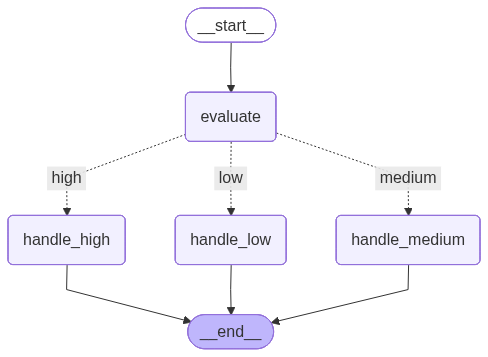

In [22]:
control_graph = control_graph.compile()
visualize_graph(control_graph)

<br>

#### 상태 전달
- **노드 간 이동 시 상태 정보가 손실 없이 전달되도록 보장하며, 필요에 따라 상태 변환이나 필터링을 적용 가능**
- **리듀서(reducer)와 함께 사용될 때, 여러 노드의 출력을 적절히 병합하거나 누적할 수 있어 복잡한 데이터 처리 파이프라인을 구현가능**
- **상태 전달에서 중요한 개념은 상태 불변성과 부분 업데이트**
  - 각 노드는 전체 상태를 덮어쓰는 것이 아니라 필요한 부분만 업데이트하고, 나머지 상태는 그대로 유지
  
  $\rightarrow$ **이는 상태 관리의 복잡성을 줄이고 예측 가능한 동작을 보장**

In [25]:
from typing import Annotated
import operator

In [27]:
class StateTransferExample(TypedDict):
    """상태 전달 예시"""
    accumulator: Annotated[list, operator.add]  # 리듀서로 누적
    current_value: int
    transformations: list

- 노드 함수 정의

In [28]:
def transform_add_10(state: StateTransferExample) -> dict:
    """값에 10을 더하고 변환 기록"""
    new_value = state["current_value"] + 10
    return {
        "current_value": new_value,
        "accumulator": [new_value],
        "transformations": state.get("transformations", []) + ["add_10"]
    }

In [29]:
def transform_multiply_2(state: StateTransferExample) -> dict:
    """값을 2배로 만들고 변환 기록"""
    new_value = state["current_value"] * 2
    return {
        "current_value": new_value,
        "accumulator": [new_value],
        "transformations": state["transformations"] + ["multiply_2"]
    }

In [30]:
def transform_square(state: StateTransferExample) -> dict:
    """값을 제곱하고 변환 기록"""
    new_value = state["current_value"] ** 2
    return {
        "current_value": new_value,
        "accumulator": [new_value],
        "transformations": state["transformations"] + ["square"]
    }

- 노드 & 엣지 구성

In [31]:
# 상태 전달 체인 구성
transfer_graph = StateGraph(StateTransferExample)
transfer_graph.add_node("add_10", transform_add_10)
transfer_graph.add_node("multiply_2", transform_multiply_2)
transfer_graph.add_node("square", transform_square)

# 엣지를 통한 상태 전달
transfer_graph.add_edge(START, "add_10")
transfer_graph.add_edge("add_10", "multiply_2")
transfer_graph.add_edge("multiply_2", "square")
transfer_graph.add_edge("square", END)

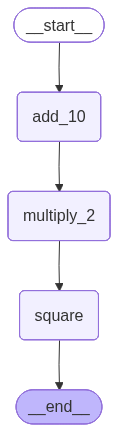

In [32]:
compiled_transfer = transfer_graph.compile()
visualize_graph(compiled_transfer)

In [ ]:
result = compiled_transfer.invoke({
    "accumulator": [],
    "current_value": 5,
    "transformations": []
})

print(f"초기값: 5")
print(f"변환 과정: {result['accumulator']}")  # [15, 30, 900]
print(f"최종값: {result['current_value']}")   # 900
print(f"적용된 변환: {result['transformations']}")  # ['add_10', 'multiply_2', 'square']

초기값: 5
변환 과정: [15, 30, 900]
최종값: 900
적용된 변환: ['add_10', 'multiply_2', 'square']


<br>

### 조건부 엣지 (Conditional Edges)

1. **유연한 대응** : 사용자의 다양한 입력에 맞게 다르게 반응
2. **효율적인 처리** : 필요한 경우에만 특정 작업을 실행해서 시간을 절약
3. **스마트한 동작** : 상황에 맞는 적절한 응답을 제공

<br>

#### 기본 문법: `add_conditional_edges`
- **`source_node`**: 조건 검사를 시작할 노드
- **`condition_function`**: 현재 상태를 평가하고 다음 노드를 결정하는 함수

<br>


```python
from langgraph.graph import StateGraph, END

workflow = StateGraph(State)

workflow.add_conditional_edges(
    "source_node",
    condition_function,
    {
        "condition1": "target_node1",
        "condition2": "target_node2",
        "default": END
    }
)
```

<br>

#### `condition_function`의 역할
- **`condition_function`은 현재 상태를 평가하고 다음에 어떤 노드로 이동할지 결정하는 중요한 역할**
  - **입력**: 현재 상태(State)를 입력으로 받음
  - **출력**: 문자열 또는 열거형(Enum) 값을 반환. 이 값은 다음에 실행될 노드를 결정
  - **로직**: 상태를 분석하여 조건에 따라 다른 값을 반환


<br>

```python
from typing import Literal

def check_user_input(state: State) -> Literal["question", "command", "unknown"]:
    user_input = state["user_input"].lower()

    if user_input.endswith("?"):
        return "question"
    elif user_input.startswith("!"):
        return "command"
    else:
        return "unknown"

workflow.add_conditional_edges(
    "parse_input",
    check_user_input,
    {
        "question": "answer_question",
        "command": "execute_command",
        "unknown": "ask_clarification"
    }
)
```

<br>

#### `condition_function` 설계에서의 고려사항

> 1. 모든 가능한 상황을 고려했는지 확인
>
> 2. 함수의 로직을 간단하고 명확하게 유지
>
> 3. 필요한 경우 여러 개의 작은 함수로 나누어 복잡한 조건을 처리
>
> 4. 테스트를 통해 모든 조건이 예상대로 작동하는지 확인
>

<br>

#### 간단한 조건 분기 - 숫자 크기 비교하기
- 숫자를 받아서 10보다 큰지 작은지 판단하는 프로그램

<br>


In [39]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [40]:
class NumberState(TypedDict):
    number: int
    result: str

<br>

- 노드 함수 정의

In [41]:
# Node 1: 큰 숫자 처리
def handle_big_number(state):
    return {"result": f"{state['number']}는 큰 숫자입니다!"}

In [42]:
# Node 2: 작은 숫자 처리
def handle_small_number(state):
    return {"result": f"{state['number']}는 작은 숫자입니다!"}

In [43]:
# 조건 함수: 어디로 갈지 결정
def check_size(state):
    if state["number"] > 10:
        return "big"     # 큰 숫자면 "big"
    else:
        return "small"   # 작은 숫자면 "small"

<br>

- 그래프 구성

In [44]:
graph = StateGraph(NumberState)
graph.add_node("big_handler", handle_big_number)
graph.add_node("small_handler", handle_small_number)

In [45]:
# 조건부 엣지 추가
graph.add_conditional_edges(
    START,
    check_size,
    {
        "big": "big_handler",      # "big"이면 big_handler로
        "small": "small_handler"   # "small"이면 small_handler로
    }
)

In [46]:
graph.add_edge("big_handler", END)
graph.add_edge("small_handler", END)

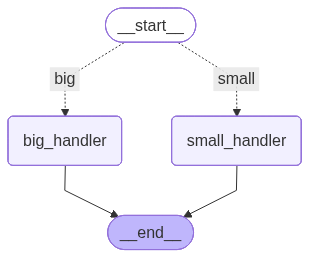

In [47]:
app = graph.compile()
visualize_graph(app)

In [48]:
result1 = app.invoke({"number": 15, "result": ""})
print(result1)

# 작은 숫자로 테스트
result2 = app.invoke({"number": 5, "result": ""})
print(result2)

{'number': 15, 'result': '15는 큰 숫자입니다!'}
{'number': 5, 'result': '5는 작은 숫자입니다!'}


<br>

#### 간단한 조건 분기 - 신호등 시스템
- 색깔에 따라 다른 행동을 하는 신호등 시스템

<br>

In [49]:
class TrafficState(TypedDict):
    color: str
    action: str

<br>

- 노드 함수 정의

In [50]:
def red_light(state):
    return {"action": "정지하세요! 🛑"}

def yellow_light(state):
    return {"action": "주의하세요! ⚠️"}

def green_light(state):
    return {"action": "출발하세요! 🟢"}

In [51]:
# 조건 함수: 색깔에 따라 결정
def check_color(state):
    color = state["color"].lower()
    if color == "red":
        return "red"
    elif color == "yellow":
        return "yellow"
    else:
        return "green"

- 그래프 구성

In [52]:
graph = StateGraph(TrafficState)
graph.add_node("red", red_light)
graph.add_node("yellow", yellow_light)
graph.add_node("green", green_light)

In [53]:
# 조건부 엣지 - 3가지 경로
graph.add_conditional_edges(
    START,
    check_color,
    {
        "red": "red",
        "yellow": "yellow",
        "green": "green"
    }
)

In [ ]:
# 모든 노드를 END로 연결
graph.add_edge("red", END)
graph.add_edge("yellow", END)
graph.add_edge("green", END)

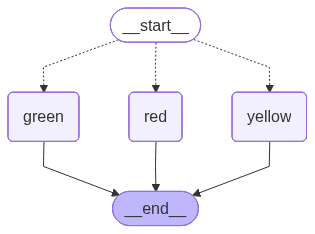

In [55]:
app = graph.compile()
visualize_graph(app)

In [56]:
colors = ["red", "yellow", "green", "blue"]
for color in colors:
    result = app.invoke({"color": color, "action": ""})
    print(f"{color} → {result['action']}")

red → 정지하세요! 🛑
yellow → 주의하세요! ⚠️
green → 출발하세요! 🟢
blue → 출발하세요! 🟢


<br>

#### 기본 조건부 엣지 - 감정 분석
- **기본 조건부 엣지의 핵심은 라우팅 함수와 경로 매핑**
  - 라우팅 함수는 현재 상태를 분석하여 다음에 실행할 노드를 결정하는 로직
  
  `Literal` 타입을 사용하여 가능한 모든 경로를 명시적으로 정의함으로써 타입 안전성을 보장
  
  $\rightarrow$  **컴파일 시점에서 오타나 잘못된 경로 참조를 방지하는 중요한 역할**


<br>

- **조건부 엣지의 동작 메커니즘**
  - 소스 노드가 실행되어 상태를 업데이트하고, 이후 라우팅 함수가 호출되어 업데이트된 상태를 기반으로 다음 노드를 선택
  - 선택된 노드는 경로 매핑 딕셔너리를 통해 실제 노드 이름으로 변환되며, 해당 노드가 실행
  - 이 과정에서 상태는 지속적으로 유지되고 전달

<br>



In [67]:
from typing import Literal

In [68]:
class ConditionalState(TypedDict):
    user_input: str
    sentiment: str
    response: str

- 노드 함수 정의

In [69]:
def analyze_sentiment(state: ConditionalState) -> dict:
    """감정 분석 노드"""
    text = state["user_input"].lower()

    # 간단한 감정 분석 (실제로는 ML 모델 사용)
    if any(word in text for word in ["happy", "great", "awesome", "love"]):
        sentiment = "positive"
    elif any(word in text for word in ["sad", "bad", "hate", "terrible"]):
        sentiment = "negative"
    else:
        sentiment = "neutral"

    return {"sentiment": sentiment}

In [70]:
def positive_response(state: ConditionalState) -> dict:
    """긍정적 응답 생성"""
    return {"response": f"😊 That's wonderful! I'm glad you feel that way about: {state['user_input']}"}

def negative_response(state: ConditionalState) -> dict:
    """부정적 응답 생성"""
    return {"response": f"😔 I understand that's difficult. Let me help with: {state['user_input']}"}

def neutral_response(state: ConditionalState) -> dict:
    """중립적 응답 생성"""
    return {"response": f"📝 I see. Let me process your request: {state['user_input']}"}

In [71]:
# 라우팅 함수
def sentiment_router(state: ConditionalState) -> Literal["positive", "negative", "neutral"]:
    """감정에 따라 라우팅"""
    return state["sentiment"]

<br>

- 그래프 구성

In [72]:
# 조건부 엣지를 사용한 그래프
sentiment_graph = StateGraph(ConditionalState)
sentiment_graph.add_node("analyze", analyze_sentiment)
sentiment_graph.add_node("positive", positive_response)
sentiment_graph.add_node("negative", negative_response)
sentiment_graph.add_node("neutral", neutral_response)

In [73]:
# 조건부 엣지 설정
sentiment_graph.add_edge(START, "analyze")
sentiment_graph.add_conditional_edges(
    "analyze",
    sentiment_router,
    {
        "positive": "positive",
        "negative": "negative",
        "neutral": "neutral"
    }
)

In [74]:
sentiment_graph.add_edge("positive", END)
sentiment_graph.add_edge("negative", END)
sentiment_graph.add_edge("neutral", END)

In [ ]:
sentiment_graph = sentiment_graph.compile()

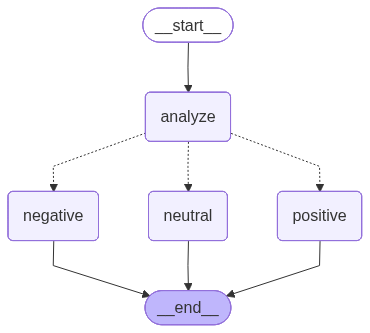

In [76]:
visualize_graph(sentiment_graph)

<br>

### 복잡한 조건부 라우팅
- **복잡한 조건부 라우팅에서는 단순한 이진 분기를 넘어서 다중 조건, 범위 기반 분기, 우선순위 기반 선택 등 복잡한 비즈니스 로직을 구현**
- 여러 변수를 조합한 복합 조건 평가를 통해 최적의 처리 경로를 동적으로 결정할 수 있으며, 이는 리소스 할당, 성능 최적화, 사용자 경험 개선 등에 활용

In [77]:
from typing import Union, List

In [78]:
class ComplexRoutingState(TypedDict):
    priority: int
    data_size: int
    processing_mode: str
    routes_taken: list

- 노드 함수 정의

In [79]:
def initial_assessment(state: ComplexRoutingState) -> dict:
    """초기 평가 및 라우팅 준비"""
    # 복합 조건 평가
    if state["priority"] >= 8 and state["data_size"] < 1000:
        mode = "express"
    elif state["priority"] >= 5 and state["data_size"] < 10000:
        mode = "standard"
    elif state["data_size"] > 100000:
        mode = "batch"
    else:
        mode = "economy"

    return {
        "processing_mode": mode,
        "routes_taken": ["assessment"]
    }

In [80]:
def express_processing(state: ComplexRoutingState) -> dict:
    """고속 처리"""
    return {
        "routes_taken": state["routes_taken"] + ["express"],
        "processing_mode": "express_complete"
    }

def standard_processing(state: ComplexRoutingState) -> dict:
    """표준 처리"""
    return {
        "routes_taken": state["routes_taken"] + ["standard"],
        "processing_mode": "standard_complete"
    }

def batch_processing(state: ComplexRoutingState) -> dict:
    """배치 처리"""
    return {
        "routes_taken": state["routes_taken"] + ["batch"],
        "processing_mode": "batch_complete"
    }

def economy_processing(state: ComplexRoutingState) -> dict:
    """경제 처리"""
    return {
        "routes_taken": state["routes_taken"] + ["economy"],
        "processing_mode": "economy_complete"
    }


In [81]:
# 라우팅 함수
def complex_router(state: ComplexRoutingState) -> Union[str, List[str]]:
    """
    복잡한 라우팅 로직
    단일 노드 또는 여러 노드로 라우팅 가능
    """
    mode = state["processing_mode"]

    # 단일 라우팅
    if mode in ["express", "standard", "batch", "economy"]:
        return mode

    # 다중 라우팅 (병렬 실행)
    if state["priority"] == 10:
        return ["express", "standard"]  # 두 경로 모두 실행

    # 기본값
    return "economy"


<br>

- 그래프 구성

In [82]:
complex_graph = StateGraph(ComplexRoutingState)
complex_graph.add_node("assessment", initial_assessment)
complex_graph.add_node("express", express_processing)
complex_graph.add_node("standard", standard_processing)
complex_graph.add_node("batch", batch_processing)
complex_graph.add_node("economy", economy_processing)

In [83]:
complex_graph.add_edge(START, "assessment")
complex_graph.add_conditional_edges(
    "assessment",
    complex_router,
    {
        "express": "express",
        "standard": "standard",
        "batch": "batch",
        "economy": "economy"
    }
)

In [84]:
for node in ["express", "standard", "batch", "economy"]:
    complex_graph.add_edge(node, END)

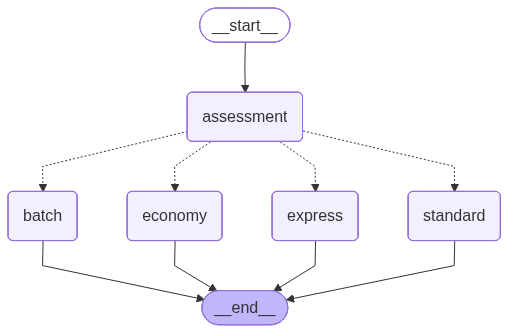

In [85]:
complex_graph = complex_graph.compile()
visualize_graph(complex_graph)

<br>

#### 조건부 엣지의 다양한 측면
- **다중 라우팅과 병렬 실행**
  - 다중 라우팅과 병렬 실행은 조건부 엣지의 고급 기능으로, 특정 조건에서 여러 노드를 동시에 실행할 수 있게 해줌
  - `Union[str, List[str]]` 타입을 반환하는 라우터 함수를 통해 구현되며, 결과 비교, 백업 처리, 성능 향상 등의 목적으로 활용
  
  예) 중요한 요청의 경우 여러 처리 방식을 동시에 실행하여 가장 빠른 결과를 사용하거나 결과를 교차 검증

<br>

- **상태 기반 의사결정**
  - 상태 기반 의사결정에서 조건부 엣지는 현재 상태뿐만 아니라 이전 처리 이력, 외부 환경, 사용자 프로필 등 다양한 요소를 고려하여 최적의 경로를 선택
  - 개인화된 워크플로우, 적응형 처리, 컨텍스트 인식 시스템 등을 구현 가능

<br>

- **성능 최적화**
  - 성능 최적화에서 조건부 엣지는 불필요한 계산을 피하고 리소스를 효율적으로 사용할 수 있게 해줌
  - 데이터 크기에 따른 처리 방식 선택, 시스템 부하에 따른 경로 조정, 우선순위 기반 리소스 할당 등을 통해 전체 시스템의 성능을 향상

<br>

- **에러 처리와 복구 전략**
  - 에러 처리와 복구 전략에서 조건부 엣지는 예외 상황에서 대안 경로를 제공하는 중요한 역할
  - 특정 노드에서 오류가 발생했을 때 다른 처리 방식으로 자동 전환하거나, 재시도 로직을 구현하거나, 우아한 성능 저하(graceful degradation)를 제공

<br>

### Command를 활용한 고급 흐름 제어

<br>

#### Command
- Command는 LangGraph에서 "다음에 어디로 갈지"와 "상태를 어떻게 바꿀지"를 한 번에 결정할 수 있는 혁신적인 기능으로, 기존 조건부 엣지의 한계를 뛰어넘어 더욱 유연한 워크플로우 제어를 가능
-  이는 복잡한 비즈니스 로직을 보다 쉽고 효율적으로 구현할 수 있는 핵심 도구
- Command의 핵심 가치는 원자적 연산(Atomic Operation) 에 있습니다. 전통적인 방식에서는 라우팅 결정과 상태 업데이트가 별도의 단계로 분리되어 있어 중간 상태의 불일치나 복잡한 동기화 문제가 발생할 수 있었습니다. Command는 이 두 작업을 하나의 원자적 연산으로 통합하여 데이터 일관성을 보장하고 시스템의 안정성을 크게 향상시킵니다.
- 예) 쇼핑몰 주문 처리 시스템에서 재고 확인 결과에 따라 다른 경로로 분기하면서 동시에 고객에게 보여줄 메시지를 업데이트하고, 주문 상태를 변경하고, 로그를 기록하는 등의 복잡한 작업을 하나의 Command로 처리
  
  $\rightarrow$ 코드의 간결성뿐만 아니라 비즈니스 로직의 명확성도 크게 향상